## ENGENHARIA DE ATRIBUTOS

In [50]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import math

In [51]:
df = pd.read_csv('data/df_model.csv')

In [52]:
df.dtypes

campaign_id                   str
date                          str
category                      str
objective                     str
target_audience_age           str
is_retargeting               bool
has_subtitle                int64
has_cta                      bool
has_hook                     bool
has_face                     bool
music_voice_ratio         float64
conversions               float64
engagement_rate           float64
klike_score               float64
impressions_lg_mm         float64
clicks_lg_mm              float64
spend_lg_mm               float64
revenue_lg_mm             float64
conversions_lg_mm         float64
video_duration_s_lg_mm    float64
avg_watch_time_s_lg_mm    float64
ctr_lg_mm                 float64
roas_lg_mm                float64
cpc_lg_mm                 float64
platform                      str
text_density                  str
format                        str
platform_LinkedIn            bool
platform_Meta                bool
platform_TikTo

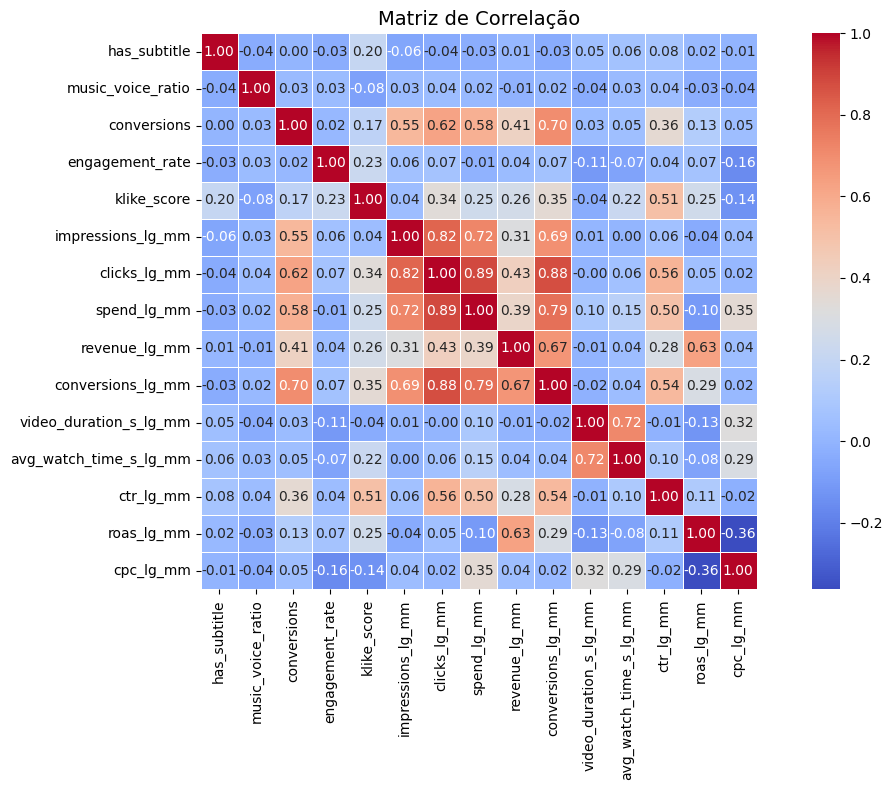

In [53]:
corr = df.select_dtypes(include='number').corr()
plt.figure(figsize=(12, 8))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    square=True,
    linewidths=0.5
)

plt.title("Matriz de Correlação", fontsize=14)
plt.tight_layout()
plt.show()

In [54]:
df.dtypes

campaign_id                   str
date                          str
category                      str
objective                     str
target_audience_age           str
is_retargeting               bool
has_subtitle                int64
has_cta                      bool
has_hook                     bool
has_face                     bool
music_voice_ratio         float64
conversions               float64
engagement_rate           float64
klike_score               float64
impressions_lg_mm         float64
clicks_lg_mm              float64
spend_lg_mm               float64
revenue_lg_mm             float64
conversions_lg_mm         float64
video_duration_s_lg_mm    float64
avg_watch_time_s_lg_mm    float64
ctr_lg_mm                 float64
roas_lg_mm                float64
cpc_lg_mm                 float64
platform                      str
text_density                  str
format                        str
platform_LinkedIn            bool
platform_Meta                bool
platform_TikTo

In [55]:
# Datas em seus formatos puros não representam informação útil para modelos
# Entretanto podemos derivar alguns atributos, como o dia da semana que foi colocado e uma flag se é final de semana
df['date'] = pd.to_datetime(df['date'])
df['dia_da_semana'] = df['date'].dt.dayofweek # 0 é segunda
df['fl_final_semana'] = df['dia_da_semana'].isin([5, 6]).astype(int)
# talvez possamos encontrar algum padrão referente à época do mes
df_dias = pd.DataFrame()
df_dias['data'] = df['date']
df_dias['dias_mes'] = df_dias['data'].dt.days_in_month
df_dias['proporcao_dia'] = df_dias['data'].dt.day/df_dias['dias_mes']
df_dias['quartil_mes'] = pd.cut(
                                df_dias['proporcao_dia'],
                                bins=[0,0.25,0.5,0.75,1],
                                labels=['inicio','meio1','meio2','fim'],
                                include_lowest=True)
mapping = {'inicio':0,'meio1':1,'meio2':2,'fim':3}
df['posicao_mes_veiculacao'] = df_dias['quartil_mes'].map(mapping)

In [56]:
# Vamos derivar um atributo relacionado a estratégia x dia x plataforma
df['objective_platform'] = df['objective'] + "_" + df['platform']
df['platform_weekend'] = df['platform'] + '_' + df['fl_final_semana'].astype(str)
df['obj_mes'] = df['objective'] + '_' + df['posicao_mes_veiculacao'].astype(str)
df = pd.get_dummies(
    df,
    columns=['objective_platform', 'platform_weekend','obj_mes'],
    drop_first=True
)

In [57]:
# transformar a duracao do vídeo em categoria facilita a análise e cria features robustas a outliers

df['video_duration_cat'] = pd.cut(
    df['video_duration_s_lg_mm'],
    bins=[0, 10, 20, 40, 120],
    labels=['muito_curto', 'curto', 'medio', 'longo']
)



In [58]:
df['duration_obj'] = df['video_duration_cat'].astype(str) + '_' + df['objective']
df = pd.get_dummies(df, columns=['duration_obj'], drop_first=True)

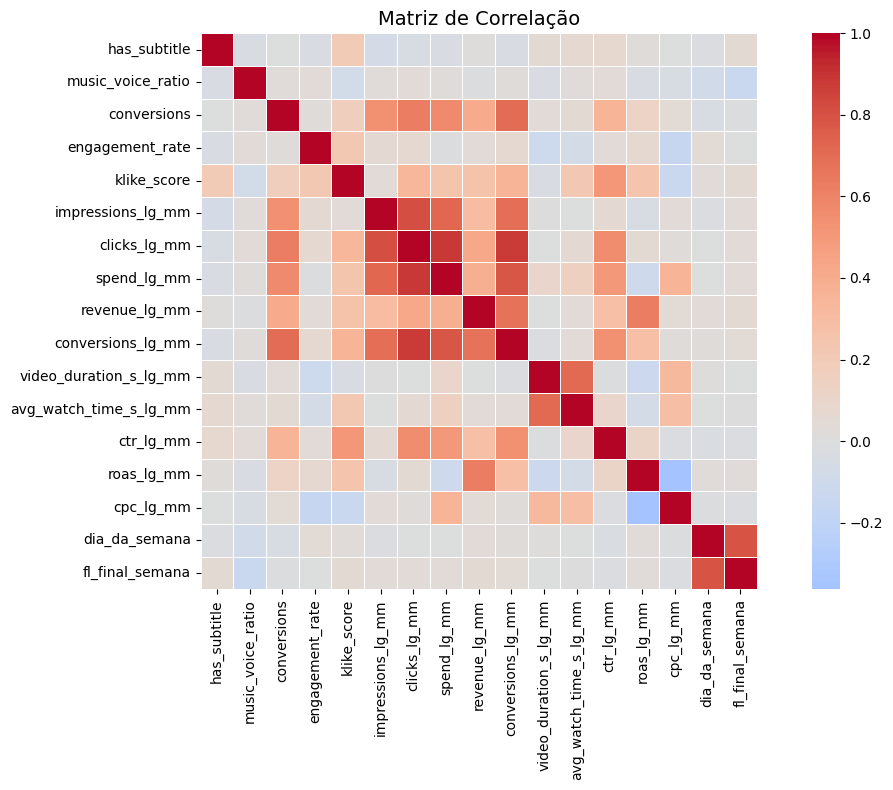

In [59]:
corr = df.select_dtypes(include='number').corr()
plt.figure(figsize=(12, 8))
sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5
)

plt.title("Matriz de Correlação", fontsize=14)
plt.tight_layout()
plt.show()

In [60]:
df['porcentagem_assistida'] = np.where(
    df['video_duration_s_lg_mm'] == 0,
    0,
    df['avg_watch_time_s_lg_mm'] / df['video_duration_s_lg_mm']
)
df['receita_x_click'] = df['revenue_lg_mm'] / (df['clicks_lg_mm'] + 1)
df['custo_x_conversao'] = df['spend_lg_mm'] / (df['conversions'] + 1)
df['ctr_x_roas'] = df['ctr_lg_mm'] * df['roas_lg_mm']
df['engagement_rate_x_ctr'] = df['engagement_rate'] * df['ctr_lg_mm']

In [61]:
creative_cols = ['has_subtitle', 'has_cta', 'has_hook', 'has_face']
df['completude_criativa'] = df[creative_cols].sum(axis=1)  # 0 a 4

In [62]:
age_map = {'18-24': 0, '25-34': 1, '35-44': 2, '45+': 3}
df['target_audience_age_cat'] = df['target_audience_age'].map(age_map)

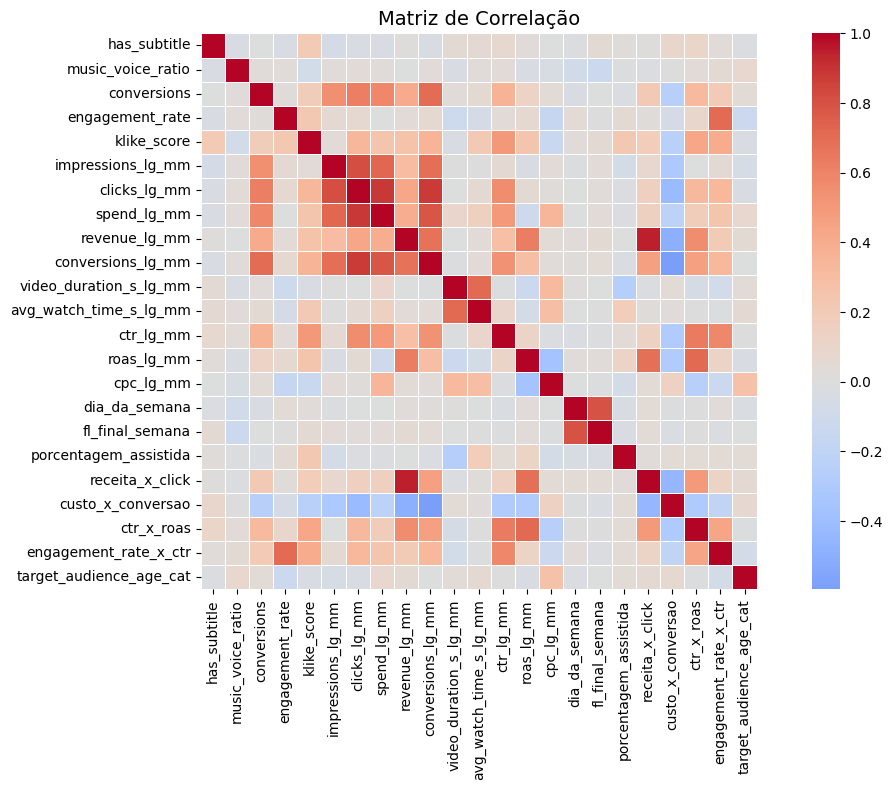

In [63]:
corr = df.select_dtypes(include='number').corr()
plt.figure(figsize=(12, 8))
sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5
)

plt.title("Matriz de Correlação", fontsize=14)
plt.tight_layout()
plt.show()

In [64]:
mapping = {'low': 0, 'medium': 1, 'high': 2}
df['text_density_cat'] = df['text_density'].map(mapping)

In [65]:
df = pd.get_dummies(
    df,
    columns=['category'],  # colunas para criar dummies
    prefix=['category']   # prefixo para as novas colunas
)

In [66]:
df['porcentagem_assistida'] = np.where(
    df['video_duration_s_lg_mm'] == 0,
    0,
    df['avg_watch_time_s_lg_mm'] / df['video_duration_s_lg_mm']
)
df['fl_replay'] = (df['avg_watch_time_s_lg_mm'] > df['video_duration_s_lg_mm']).astype(int)

df['avg_watch_time_s'] = df[['avg_watch_time_s_lg_mm', 'video_duration_s_lg_mm']].min(axis=1)


In [67]:
df.columns

Index(['campaign_id', 'date', 'objective', 'target_audience_age',
       'is_retargeting', 'has_subtitle', 'has_cta', 'has_hook', 'has_face',
       'music_voice_ratio', 'conversions', 'engagement_rate', 'klike_score',
       'impressions_lg_mm', 'clicks_lg_mm', 'spend_lg_mm', 'revenue_lg_mm',
       'conversions_lg_mm', 'video_duration_s_lg_mm', 'avg_watch_time_s_lg_mm',
       'ctr_lg_mm', 'roas_lg_mm', 'cpc_lg_mm', 'platform', 'text_density',
       'format', 'platform_LinkedIn', 'platform_Meta', 'platform_TikTok',
       'text_density_high', 'text_density_low', 'text_density_medium',
       'format_horizontal', 'format_quadrado', 'format_vertical',
       'dia_da_semana', 'fl_final_semana', 'posicao_mes_veiculacao',
       'objective_platform_app_install_Meta',
       'objective_platform_app_install_TikTok',
       'objective_platform_awareness_LinkedIn',
       'objective_platform_awareness_Meta',
       'objective_platform_awareness_TikTok',
       'objective_platform_conversions

In [68]:
df['has_hook_Meta'] = df['has_hook'] * df['platform_Meta']
df['has_face_TikTok'] = df['has_face'] * df['platform_TikTok']

In [69]:
df['text_density_horizontal_Meta'] = df['text_density_high'] * df['format_horizontal'] * df['platform_Meta']

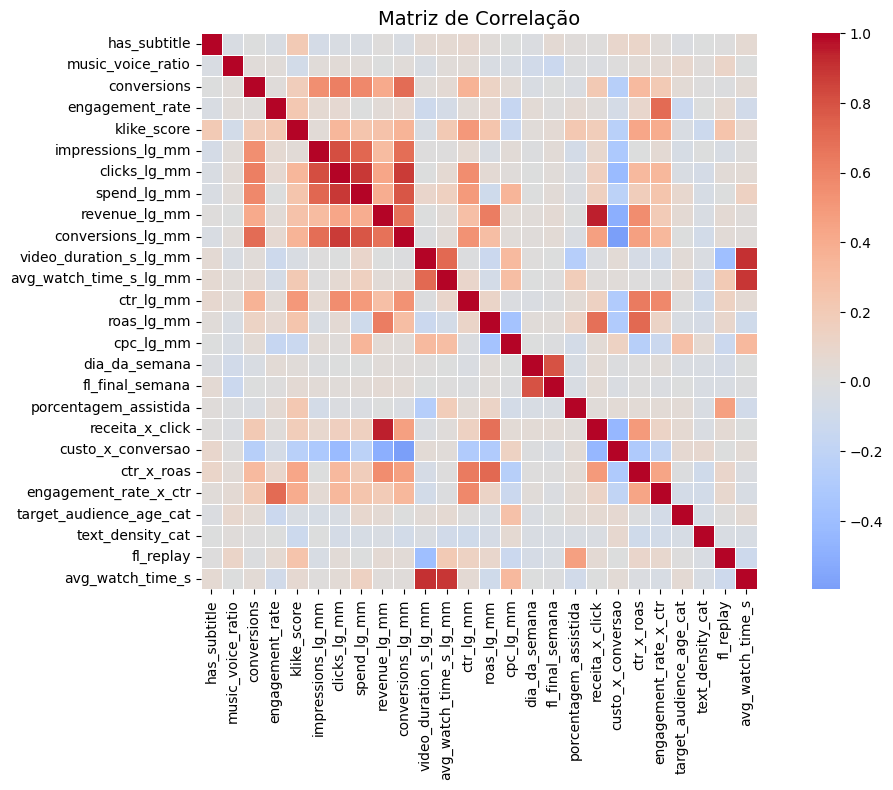

In [70]:
corr = df.select_dtypes(include='number').corr()
plt.figure(figsize=(12, 8))
sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5
)

plt.title("Matriz de Correlação", fontsize=14)
plt.tight_layout()
plt.show()

C:\Users\mathe\AppData\Local\Temp\ipykernel_85644\651572807.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=klike_corr.values, y=klike_corr.index, palette="coolwarm")


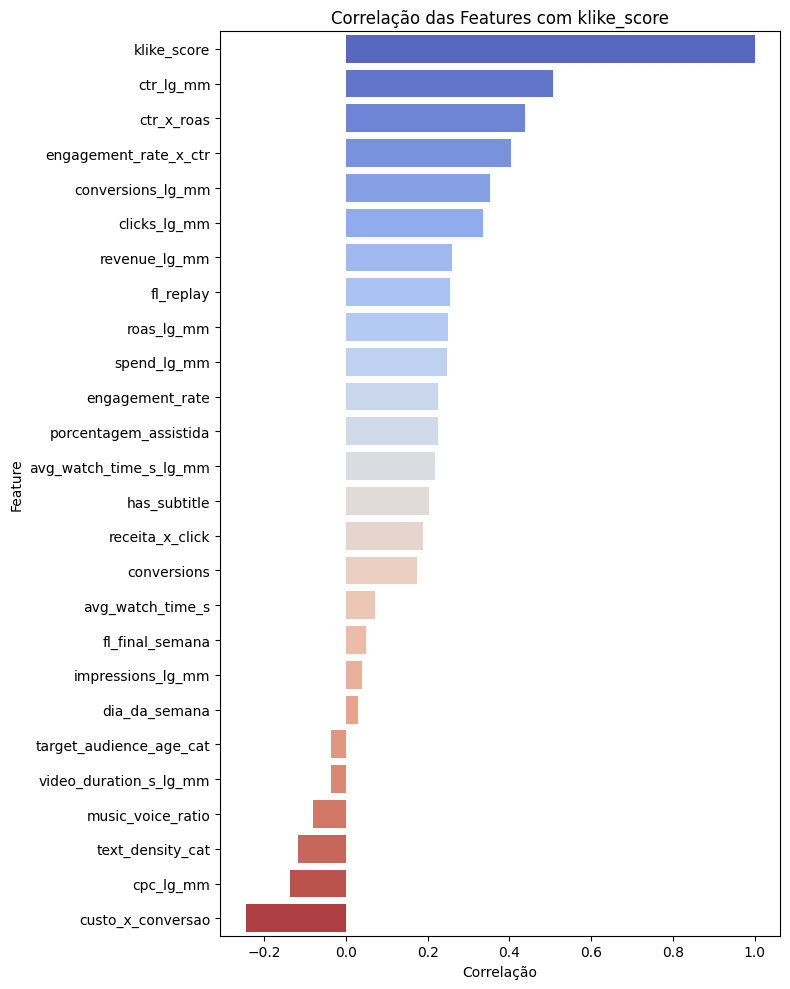

In [71]:

# Seleciona apenas colunas numéricas
num_cols = df.select_dtypes(include='number')

# Calcula correlação
corr = num_cols.corr()

# Pega apenas a coluna de interesse
klike_corr = corr['klike_score'].sort_values(ascending=False)

# Mostra as correlações em gráfico de barras
plt.figure(figsize=(8, 10))
sns.barplot(x=klike_corr.values, y=klike_corr.index, palette="coolwarm")
plt.title("Correlação das Features com klike_score")
plt.xlabel("Correlação")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

## MODELO

In [72]:
from sklearn.model_selection import train_test_split

In [73]:
colunas_drop_modelo = [
    'campaign_id', 'date',
    'target_audience_age',
    'text_density', 'format',
    'video_duration_cat', 'impressions_cat', 'conversions_cat',
    'best_pos_mes_obj', 'is_best_moment', 'conv_rate'  # removidas do drop pois serão recriadas
]
df_model = df.drop(columns=colunas_drop_modelo, errors='ignore')


In [74]:
bool_cols = df_model.select_dtypes(include='bool').columns
df_model[bool_cols] = df_model[bool_cols].astype(int)

cat_cols = df_model.select_dtypes(include='category').columns
for col in cat_cols:
    if pd.api.types.is_numeric_dtype(df_model[col].cat.categories):
        df_model[col] = df_model[col].cat.codes.astype(int)

object_cols = df_model.select_dtypes(include='object').columns
for col in object_cols:
    # tenta converter para número
    try:
        df_model[col] = pd.to_numeric(df_model[col])
    except ValueError:
        # se não der, converte para categoria e depois para int
        df_model[col] = df_model[col].astype('category').cat.codes.astype(int)

C:\Users\mathe\AppData\Local\Temp\ipykernel_85644\3954928953.py:9: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  object_cols = df_model.select_dtypes(include='object').columns


In [75]:
X = df_model.drop(columns=['klike_score'])
y = df_model['klike_score']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)


In [76]:
_, bins_imp = pd.qcut(X_train['impressions_lg_mm'], q=4, retbins=True, duplicates='drop')
_, bins_con = pd.qcut(X_train['conversions_lg_mm'] if 'conversions_lg_mm' in X_train.columns 
                      else X_train['conversions'],   q=4, retbins=True, duplicates='drop')

df_group = X_train.copy()
df_group['y'] = y_train.values

df_agg = df_group.groupby(['objective', 'posicao_mes_veiculacao']).agg(
    conversions=('y', 'sum'),          # usa o target só pra ranquear, não vaza pq é só do treino
    impressions=('impressions_lg_mm', 'sum')
).reset_index()
df_agg['conv_rate'] = df_agg['conversions'] / df_agg['impressions'].replace(0, np.nan)

df_best  = df_agg.loc[df_agg.groupby('objective')['conv_rate'].idxmax()]
best_map = dict(zip(df_best['objective'], df_best['posicao_mes_veiculacao']))
conv_rate_map = df_agg.set_index(['objective', 'posicao_mes_veiculacao'])['conv_rate']

platform_mean = X_train.groupby('platform')['spend_lg_mm'].mean()


In [77]:
for split in [X_train, X_test]:
    split['impressions_cat'] = pd.cut(
        split['impressions_lg_mm'], bins=bins_imp,
        labels=['baixo', 'medio_baixo', 'medio_alto', 'alto'],
        include_lowest=True
    ).cat.codes.astype(int)

    split['best_pos_mes_obj'] = split['objective'].map(best_map)
    split['is_best_moment']   = (split['posicao_mes_veiculacao'] == split['best_pos_mes_obj']).astype(int)
    split['conv_rate']        = list(zip(split['objective'], split['posicao_mes_veiculacao']))
    split['conv_rate']        = split['conv_rate'].map(lambda k: conv_rate_map.get(k, np.nan))
    split['custo_x_plataforma'] = split['spend_lg_mm'] / split['platform'].map(platform_mean)

In [78]:

cols_drop_final = ['objective', 'platform', 'posicao_mes_veiculacao']
X_train = X_train.drop(columns=cols_drop_final, errors='ignore')
X_test  = X_test.drop(columns=cols_drop_final, errors='ignore')

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (350, 94)
X_test shape: (150, 94)


In [80]:
from xgboost import XGBRegressor

model = XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    random_state=42,
    objective='reg:absoluteerror'
)

model.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:absoluteerror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabete

In [81]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

y_pred = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"R²: {r2:.4f}")

RMSE: 7.0295
MAE: 5.5545
R²: 0.7795


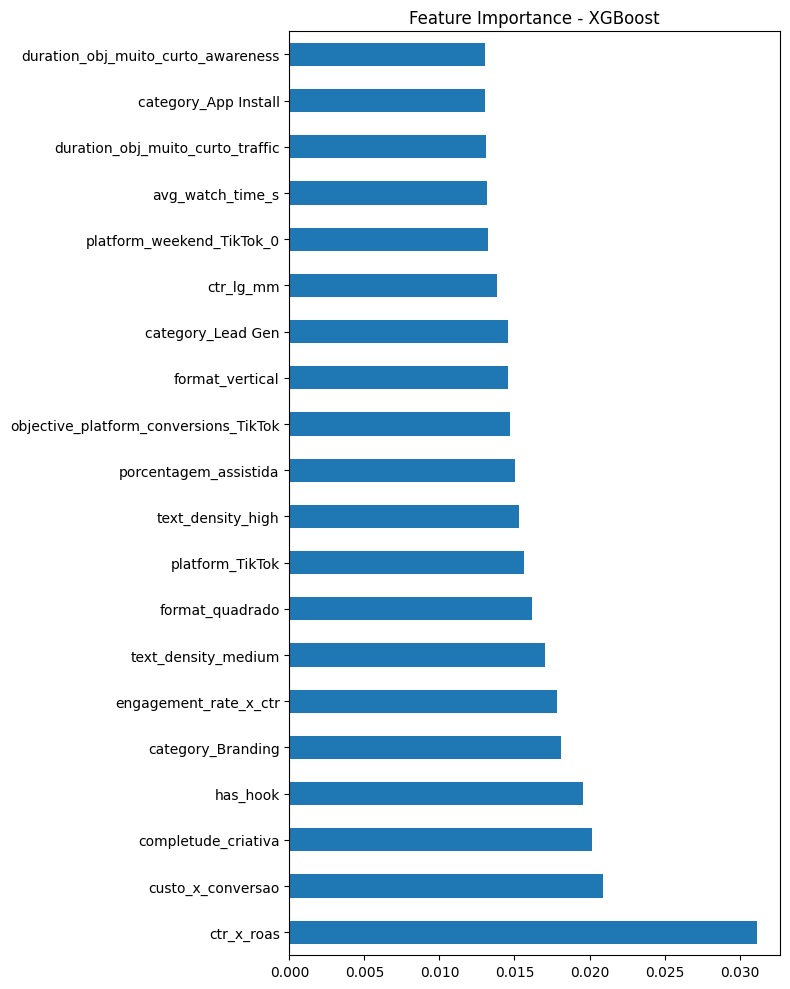

In [86]:


importances = model.feature_importances_
feat_imp = pd.Series(importances, index=X_train.columns).sort_values(ascending=False).head(20)

feat_imp.plot(kind='barh', figsize=(8, 10))
plt.title('Feature Importance - XGBoost')
plt.tight_layout()
plt.show()

In [82]:
import dice_ml
from dice_ml import Dice

mediana = X_train.median()
X_train_dice = X_train.fillna(mediana)
X_test_dice = X_test.fillna(mediana)

# Garantir que flags binárias sejam float
binary_cols = ['has_subtitle', 'has_cta', 'has_hook', 'has_face']
for col in binary_cols:
    X_train_dice[col] = X_train_dice[col].astype(float)
    X_test_dice[col] = X_test_dice[col].astype(float)

df_dice = X_train_dice.copy()
df_dice['klike_score'] = y_train.values

d = dice_ml.Data(
    dataframe=df_dice,
    continuous_features=X_train_dice.columns.tolist(),
    outcome_name='klike_score'
)

m = dice_ml.Model(model=model, backend="sklearn", model_type="regressor")
exp = Dice(d, m, method="random")

features_acionaveis = [
    'has_subtitle', 'has_cta', 'has_hook', 'has_face',
    'music_voice_ratio', 'porcentagem_assistida',
    'completude_criativa', 'text_density_cat'
]

permitted_range = {
    'has_subtitle': [0.0, 1.0],
    'has_cta': [0.0, 1.0],
    'has_hook': [0.0, 1.0],
    'has_face': [0.0, 1.0],
    'completude_criativa': [0.0, 4.0],
    'text_density_cat': [0.0, 2.0],
    'music_voice_ratio': [0.0, 1.0],
    'porcentagem_assistida': [0.0, 1.0],
}

def gerar_sugestoes(amostra, score_alvo_min=None, score_alvo_max=None, total_CFs=5):
    score_atual = model.predict(amostra)[0]
    score_max_treino = float(y_train.max())
    
    score_min = score_alvo_min if score_alvo_min else score_atual + 10
    score_max = score_alvo_max if score_alvo_max else score_atual + 30
    score_max = min(score_max, score_max_treino)
    
    # Se não há espaço suficiente para melhorar
    if score_min >= score_max_treino:
        print(f"Score atual {score_atual:.2f} já está próximo do máximo ({score_max_treino:.2f}). Sem sugestões.")
        return None, score_atual
    
    # Se o range ficou muito pequeno, ajusta o min
    if score_min >= score_max:
        score_min = score_atual + 5
        score_max = score_max_treino
    
    print(f"Score atual: {score_atual:.2f}")
    print(f"Buscando contrafactuais entre {score_min:.2f} e {score_max:.2f}")
    
    contrafactuais = exp.generate_counterfactuals(
        amostra,
        total_CFs=total_CFs,
        desired_range=[score_min, score_max],
        features_to_vary=features_acionaveis,
        permitted_range=permitted_range
    )
    
    return contrafactuais, score_atual

# Pior amostra do X_test
amostra = X_test_dice.iloc[[y_test.values.argmin()]]
contrafactuais, score_atual = gerar_sugestoes(amostra)
contrafactuais.visualize_as_dataframe(show_only_changes=True)

Score atual: 31.49
Buscando contrafactuais entre 41.49 e 61.49


100%|██████████| 1/1 [00:00<00:00,  4.29it/s]

Query instance (original outcome : 31.0)


,is_retargeting,has_subtitle,has_cta,has_hook,has_face,music_voice_ratio,conversions,engagement_rate,impressions_lg_mm,clicks_lg_mm,...,avg_watch_time_s,has_hook_Meta,has_face_TikTok,text_density_horizontal_Meta,impressions_cat,best_pos_mes_obj,is_best_moment,conv_rate,custo_x_plataforma,klike_score
0,0,0.0,1.0,0.0,0.0,0.41,87.0,0.0023,0.68303,0.596635,...,0.484852,0,0,0,3,3,0,131.528473,1.146846,31.0



Diverse Counterfactual set (new outcome: [np.float32(41.49345), np.float32(61.49345)])


,is_retargeting,has_subtitle,has_cta,has_hook,has_face,music_voice_ratio,conversions,engagement_rate,impressions_lg_mm,clicks_lg_mm,...,avg_watch_time_s,has_hook_Meta,has_face_TikTok,text_density_horizontal_Meta,impressions_cat,best_pos_mes_obj,is_best_moment,conv_rate,custo_x_plataforma,klike_score
0,-,-,-,0.8,-,-,-,-,-,-,...,-,-,-,-,-,-,-,-,-,44.15485382080078
1,-,-,-,-,-,-,-,-,-,-,...,-,-,-,-,-,-,-,-,-,42.960086822509766
2,-,-,-,-,-,-,-,-,-,-,...,-,-,-,-,-,-,-,-,-,44.87995147705078
3,-,-,0.3,-,-,-,-,-,-,-,...,-,-,-,-,-,-,-,-,-,44.689308166503906
4,-,-,-,-,1.0,-,-,-,-,-,...,-,-,-,-,-,-,-,-,-,45.67662811279297


In [83]:
import joblib
import os

os.makedirs('models', exist_ok=True)

joblib.dump(model, 'models/xgb_klike.pkl')
joblib.dump(X_train.columns.tolist(), 'models/feature_columns.pkl')
joblib.dump(mediana, 'models/mediana_imputacao.pkl')
X_train_dice.assign(klike_score=y_train.values).to_csv('models/df_dice_train.csv', index=False)
joblib.dump(features_acionaveis, 'models/features_acionaveis.pkl')
joblib.dump(permitted_range, 'models/permitted_range.pkl')

print("Artefatos salvos!")

Artefatos salvos!
